# The Hidden Cost of Helping: Help Ripple Index (HRI)

When a blocker helps on a defender, does that defender's threat to the QB fall, and does threat rise elsewhere?

- Threat proxy: `T = c / (1 + d)`, where `d` = distance to QB (yd) and `c` = closing speed (yd/s, ≥ 0)
- `B` = drop in the target's threat after help; `C` = summed rise in the other rushers' threat
- `HRI = B − C` (units: 1/s). This describes change around the event; it is not a causal effect.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import plotly
import plotly.graph_objects as go

# Print versions so the run environment is recorded in the notebook output
print(f"python     {sys.version.split()[0]}")
for mod in (np, pd, matplotlib, plotly):
    print(f"{mod.__name__:<10} {mod.__version__}")


python     3.12.3
numpy      2.1.2
pandas     2.2.3
matplotlib 3.10.3
plotly     7.1.0


In [2]:
# Paths
DATA_DIR = Path("data")
TRACKING_DIR = DATA_DIR / "tracking"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Tracking sample rate
FPS = 10                      # NGS tracking is 10 Hz
DT = 1 / FPS

# Help detection
HELP_BLOCK_TYPES = ["BH", "PT"]   # primary assistance labels
FALLBACK_BLOCK_TYPES = ["SW"]     # used only if primary yields nothing; labelled separately
HELP_DIST = 2.0                   # yards: helper-target proximity threshold
MIN_SUSTAIN = 3                   # consecutive frames within HELP_DIST to count as help

# Threat / HRI windows (in frames)
CLOSE_LAG = 3                     # closing speed computed over 3 frames (0.3 s)
WINDOW = 4                        # frames averaged before and after the event (0.4 s)
GAP = 1                           # transition frames excluded on each side of the event

# Play window
SNAP_EVENT = "ball_snap"
END_EVENTS = ["pass_forward", "autoevent_passforward", "qb_sack", "qb_strip_sack"]

# Batch scope
N_GAMES = 5

# Manual overrides: {(gameId, playId, helperId): frameId}, used when auto-detection is unconvincing
MANUAL_EVENT_FRAMES = {}


In [3]:
def load_data(data_dir: Path = DATA_DIR):
    """Load the four metadata tables. 'NA' strings become proper missing values."""
    read = lambda name: pd.read_csv(data_dir / name, na_values=["NA"])
    games = read("games.csv")
    plays = read("plays.csv")
    players = read("players.csv")
    pff = read("pffScoutingData.csv")

    # Keep blocked-player IDs as nullable ints so they join cleanly to nflId
    pff["pff_nflIdBlockedPlayer"] = pff["pff_nflIdBlockedPlayer"].astype("Int64")
    return games, plays, players, pff

games, plays, players, pff = load_data()

# Game IDs that actually have a tracking file on disk
TRACKING_GAME_IDS = sorted(int(p.stem.split("_")[1]) for p in TRACKING_DIR.glob("tracking_*.csv"))

for name, df in [("games", games), ("plays", plays), ("players", players), ("pff", pff)]:
    print(f"{name:<8} {df.shape}")
print(f"tracking files: {len(TRACKING_GAME_IDS)}")


games    (122, 7)
plays    (8557, 32)
players  (1679, 7)
pff      (188254, 15)
tracking files: 122


In [4]:
print("pff_role counts:")
display(pff["pff_role"].value_counts(dropna=False))

block_counts = pff["pff_blockType"].value_counts(dropna=False).rename("count").to_frame()
block_counts["is_help_label"] = block_counts.index.isin(HELP_BLOCK_TYPES + FALLBACK_BLOCK_TYPES)
print("pff_blockType counts:")
display(block_counts)

# BH rows are not always pff_role == 'Pass Block' (e.g. 'Pass Route'), so selection must filter on block type
print("Roles carrying BH/PT labels:")
display(pd.crosstab(pff.loc[pff["pff_blockType"].isin(HELP_BLOCK_TYPES), "pff_role"],
                    pff.loc[pff["pff_blockType"].isin(HELP_BLOCK_TYPES), "pff_blockType"]))


pff_role counts:


pff_role
Coverage      57765
Pass Block    46057
Pass Route    39513
Pass Rush     36362
Pass           8557
Name: count, dtype: int64

pff_blockType counts:


,count,is_help_label
pff_blockType,,
NaN,140350,False
PP,24697,False
PA,6331,False
PT,5906,True
SW,3025,True
CL,2595,False
CH,1565,False
NB,1352,False
PU,886,False


Roles carrying BH/PT labels:


pff_blockType,BH,PT
pff_role,,
Pass Block,419,5898
Pass Route,24,8


In [5]:
sample_game = TRACKING_GAME_IDS[0]
sample_track = pd.read_csv(TRACKING_DIR / f"tracking_{sample_game}.csv", na_values=["NA"])
print(f"game {sample_game}: {sample_track.shape}, plays: {sample_track['playId'].nunique()}")
display(sample_track.head(3))

# Confirm the snap/end event names used in config exist in the data
events = sample_track.loc[sample_track["event"] != "None", "event"].value_counts()
display(events)


game 2021090900: (92644, 16), plays: 97


,gameId,playId,nflId,frameId,time,jerseyNumber,team,playDirection,x,y,s,a,dis,o,dir,event
0,2021090900,97,25511.0,1,2021-09-10T00:26:31Z,12.0,TB,right,37.77,24.22,0.29,0.30,0.03,165.16,84.99,NaN
1,2021090900,97,25511.0,2,2021-09-10T00:26:31Z,12.0,TB,right,37.78,24.22,0.23,0.11,0.02,164.33,92.87,NaN
2,2021090900,97,25511.0,3,2021-09-10T00:26:31Z,12.0,TB,right,37.78,24.24,0.16,0.10,0.01,160.24,68.55,NaN


event
ball_snap                    2231
pass_forward                 2116
autoevent_passforward         851
autoevent_ballsnap            667
play_action                   345
line_set                      115
pass_arrived                   69
autoevent_passinterrupted      69
run                            46
fumble_offense_recovered       23
fumble                         23
qb_sack                        23
man_in_motion                  23
pass_outcome_caught            23
pass_outcome_incomplete        23
Name: count, dtype: int64

In [6]:
EXPECTED_ROLES = {"Pass", "Pass Block", "Pass Rush", "Pass Route", "Coverage"}

# Required columns for later tasks
for df, cols in [
    (games,   {"gameId", "week"}),
    (plays,   {"gameId", "playId", "passResult", "playDescription"}),
    (players, {"nflId", "displayName", "officialPosition"}),
    (pff,     {"gameId", "playId", "nflId", "pff_role", "pff_blockType",
               "pff_nflIdBlockedPlayer", "pff_hit", "pff_hurry", "pff_sack"}),
    (sample_track, {"gameId", "playId", "nflId", "frameId", "event", "x", "y", "s", "playDirection"}),
]:
    missing = cols - set(df.columns)
    assert not missing, f"missing columns: {missing}"

# Join-key uniqueness
assert not games["gameId"].duplicated().any()
assert not plays.duplicated(["gameId", "playId"]).any()
assert not players["nflId"].duplicated().any()
assert not pff.duplicated(["gameId", "playId", "nflId"]).any()

# Label vocabulary matches what later tasks filter on
assert set(pff["pff_role"].dropna()) <= EXPECTED_ROLES, set(pff["pff_role"].dropna()) - EXPECTED_ROLES
for bt in HELP_BLOCK_TYPES:
    assert (pff["pff_blockType"] == bt).sum() > 0, f"no {bt} labels found"

# Tracking files correspond to known games, and the snap/release events exist
assert TRACKING_GAME_IDS and set(TRACKING_GAME_IDS) <= set(games["gameId"])
assert SNAP_EVENT in set(events.index)
assert set(END_EVENTS) & set(events.index), "no end-of-window events found in sample game"

# Soft check: PFF rows should map to known plays (warn rather than fail)
orphan = pff.merge(plays[["gameId", "playId"]], how="left", indicator=True)["_merge"].eq("left_only").sum()
print(f"PFF rows without a matching play: {orphan}")

print("Task 1 checks passed.")


PFF rows without a matching play: 0
Task 1 checks passed.


## 2. Select candidate help plays

A candidate is one (game, play, helper, target) row where:
- the helper has PFF block type `BH` or `PT` (or `SW` as a fallback, labelled separately) and a named target
- the target is a `Pass Rush` player on that play
- the play has exactly one QB, at least two rushers, and a dropback result of C, I, S or IN (scrambles are excluded)


In [7]:
VALID_PASS_RESULTS = ["C", "I", "S", "IN"]
KEYS = ["gameId", "playId"]

def select_candidate_plays(pff, plays, players, game_ids,
                           block_types=HELP_BLOCK_TYPES, label_source="primary"):
    """Return one row per (gameId, playId, helper_id, target_id) help candidate."""
    scope = pff[pff["gameId"].isin(game_ids)]

    # Play-level role counts
    role_counts = (
        scope.assign(n_qb=scope["pff_role"].eq("Pass"),
                     n_rushers=scope["pff_role"].eq("Pass Rush"))
             .groupby(KEYS)[["n_qb", "n_rushers"]].sum()
             .reset_index()
    )

    # Play-level pressure outcome (any rusher credited); context only, not an outcome of the help
    rush_rows = scope[scope["pff_role"].eq("Pass Rush")]
    play_pressure = (
        rush_rows.groupby(KEYS)[["pff_hit", "pff_hurry", "pff_sack"]].max()
                 .rename(columns=lambda c: c.replace("pff_", "play_"))
                 .reset_index()
    )

    # Helpers: filter on block type, not role (some BH rows are 'Pass Route')
    helpers = (
        scope.loc[scope["pff_blockType"].isin(block_types) & scope["pff_nflIdBlockedPlayer"].notna(),
                  KEYS + ["nflId", "pff_role", "pff_positionLinedUp", "pff_blockType", "pff_nflIdBlockedPlayer"]]
             .rename(columns={"nflId": "helper_id", "pff_role": "helper_role",
                              "pff_positionLinedUp": "helper_pos", "pff_nflIdBlockedPlayer": "target_id"})
    )
    helpers["target_id"] = helpers["target_id"].astype("int64")

    # Targets must be pass rushers on the same play
    targets = rush_rows[KEYS + ["nflId", "pff_positionLinedUp", "pff_hit", "pff_hurry", "pff_sack"]].rename(
        columns={"nflId": "target_id", "pff_positionLinedUp": "target_pos",
                 "pff_hit": "target_hit", "pff_hurry": "target_hurry", "pff_sack": "target_sack"})
    cand = helpers.merge(targets, on=KEYS + ["target_id"], how="inner")

    # How many *other* blockers are also on the target (evidence of a genuine double-team)
    blocks = scope.loc[scope["pff_nflIdBlockedPlayer"].notna(), KEYS + ["nflId", "pff_nflIdBlockedPlayer"]].rename(
        columns={"nflId": "other_blocker_id", "pff_nflIdBlockedPlayer": "target_id"})
    blocks["target_id"] = blocks["target_id"].astype("int64")
    shared = cand[KEYS + ["helper_id", "target_id"]].merge(blocks, on=KEYS + ["target_id"])
    shared = shared[shared["other_blocker_id"] != shared["helper_id"]]
    n_shared = shared.groupby(KEYS + ["helper_id"]).size().rename("n_other_blockers_on_target").reset_index()
    cand = cand.merge(n_shared, on=KEYS + ["helper_id"], how="left")
    cand["n_other_blockers_on_target"] = cand["n_other_blockers_on_target"].fillna(0).astype(int)

    # Play context and filters
    cand = (cand.merge(role_counts, on=KEYS)
                .merge(play_pressure, on=KEYS, how="left")
                .merge(plays[KEYS + ["passResult", "playDescription"]], on=KEYS, how="left"))
    cand = cand[(cand["n_qb"] == 1) & (cand["n_rushers"] >= 2) & cand["passResult"].isin(VALID_PASS_RESULTS)]

    # Readable names
    names = players.set_index("nflId")["displayName"]
    cand["helper_name"] = cand["helper_id"].map(names)
    cand["target_name"] = cand["target_id"].map(names)
    cand["label_source"] = label_source

    cols = KEYS + ["helper_id", "helper_name", "helper_role", "helper_pos", "pff_blockType",
                   "target_id", "target_name", "target_pos", "n_other_blockers_on_target", "n_rushers",
                   "target_hit", "target_hurry", "target_sack",
                   "play_hit", "play_hurry", "play_sack", "passResult", "playDescription", "label_source"]
    return cand[cols].sort_values(KEYS + ["helper_id"]).reset_index(drop=True)


In [8]:
# Four tiny plays; only play 1 should survive the filters
def _row(play, nfl, role, bt=None, tgt=None):
    return dict(gameId=1, playId=play, nflId=nfl, pff_role=role, pff_positionLinedUp="X",
                pff_hit=0, pff_hurry=0, pff_sack=0, pff_blockType=bt, pff_nflIdBlockedPlayer=tgt)

_pff = pd.DataFrame([
    # play 1: valid. BH helper 20 on rusher 10, with PP 21 also on rusher 10 (shared target)
    _row(1, 1, "Pass"), _row(1, 10, "Pass Rush"), _row(1, 11, "Pass Rush"),
    _row(1, 20, "Pass Route", "BH", 10), _row(1, 21, "Pass Block", "PP", 10), _row(1, 22, "Pass Block", "PP", 11),
    # play 2: only one rusher -> excluded
    _row(2, 1, "Pass"), _row(2, 10, "Pass Rush"), _row(2, 20, "Pass Block", "BH", 10),
    # play 3: target is a coverage player -> excluded
    _row(3, 1, "Pass"), _row(3, 10, "Pass Rush"), _row(3, 11, "Pass Rush"), _row(3, 12, "Coverage"),
    _row(3, 20, "Pass Block", "PT", 12),
    # play 4: scramble -> excluded
    _row(4, 1, "Pass"), _row(4, 10, "Pass Rush"), _row(4, 11, "Pass Rush"), _row(4, 20, "Pass Block", "BH", 10),
])
_pff["pff_nflIdBlockedPlayer"] = _pff["pff_nflIdBlockedPlayer"].astype("Int64")
_plays = pd.DataFrame({"gameId": 1, "playId": [1, 2, 3, 4],
                       "passResult": ["C", "C", "C", "R"], "playDescription": ""})
_players = pd.DataFrame({"nflId": [1, 10, 11, 12, 20, 21, 22], "displayName": list("QABCHIJ")})

_out = select_candidate_plays(_pff, _plays, _players, game_ids=[1])
assert len(_out) == 1, _out
assert _out.loc[0, ["playId", "helper_id", "target_id"]].tolist() == [1, 20, 10]
assert _out.loc[0, "n_other_blockers_on_target"] == 1
assert _out.loc[0, "helper_role"] == "Pass Route"   # BH kept despite non-blocking role
print("Synthetic selection test passed.")


Synthetic selection test passed.


In [9]:
SCOPE_GAME_IDS = TRACKING_GAME_IDS[:N_GAMES]

candidates = select_candidate_plays(pff, plays, players, SCOPE_GAME_IDS)
if candidates.empty:
    print("No BH/PT candidates; falling back to SW (labelled separately).")
    candidates = select_candidate_plays(pff, plays, players, SCOPE_GAME_IDS,
                                        block_types=FALLBACK_BLOCK_TYPES, label_source="fallback")

# Checks on real output
assert not candidates.empty, "no candidates found in scope"
assert candidates["target_id"].notna().all()
assert (candidates["helper_id"] != candidates["target_id"]).all()
assert not candidates.duplicated(KEYS + ["helper_id"]).any()
assert candidates["gameId"].isin(SCOPE_GAME_IDS).all()
assert all((TRACKING_DIR / f"tracking_{g}.csv").exists() for g in candidates["gameId"].unique())
_is_rusher = candidates.merge(pff, left_on=KEYS + ["target_id"], right_on=KEYS + ["nflId"])["pff_role"]
assert _is_rusher.eq("Pass Rush").all() and len(_is_rusher) == len(candidates)

# Demo summary
print(f"games in scope: {len(SCOPE_GAME_IDS)}  |  candidates: {len(candidates)}  |  plays: {candidates[KEYS].drop_duplicates().shape[0]}")
display(candidates.groupby("pff_blockType").agg(
    n=("helper_id", "size"),
    share_with_other_blocker=("n_other_blockers_on_target", lambda s: (s > 0).mean().round(2)),
    target_pressured=("target_hurry", lambda s: s.fillna(0).gt(0).mean().round(2)),
))
display(candidates.query("gameId == 2021090900 and playId == 583"))   # reference play from planning
display(candidates.head(10))
print("Task 2 checks passed.")


games in scope: 5  |  candidates: 281  |  plays: 228


,n,share_with_other_blocker,target_pressured
pff_blockType,,,
BH,26,0.92,0.12
PT,255,0.92,0.06


,gameId,playId,helper_id,helper_name,helper_role,helper_pos,pff_blockType,target_id,target_name,target_pos,...,n_rushers,target_hit,target_hurry,target_sack,play_hit,play_hurry,play_sack,passResult,playDescription,label_source
1,2021090900,583,44816,Leonard Fournette,Pass Block,HB-L,BH,41263,Demarcus Lawrence,LEO,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(5:26) (Shotgun) T.Brady pass short middle to ...,primary
2,2021090900,583,46163,Alex Cappa,Pass Block,RG,PT,41363,Brent Urban,DLT,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(5:26) (Shotgun) T.Brady pass short middle to ...,primary


,gameId,playId,helper_id,helper_name,helper_role,helper_pos,pff_blockType,target_id,target_name,target_pos,...,n_rushers,target_hit,target_hurry,target_sack,play_hit,play_hurry,play_sack,passResult,playDescription,label_source
0,2021090900,137,37082,Tyron Smith,Pass Block,LT,PT,35454,Jason Pierre-Paul,ROLB,...,5,0.0,0.0,0.0,0.0,0.0,0.0,C,(13:18) (Shotgun) D.Prescott pass deep left to...,primary
1,2021090900,583,44816,Leonard Fournette,Pass Block,HB-L,BH,41263,Demarcus Lawrence,LEO,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(5:26) (Shotgun) T.Brady pass short middle to ...,primary
2,2021090900,583,46163,Alex Cappa,Pass Block,RG,PT,41363,Brent Urban,DLT,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(5:26) (Shotgun) T.Brady pass short middle to ...,primary
3,2021090900,735,46119,Connor Williams,Pass Block,LG,PT,35441,Ndamukong Suh,DRT,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(2:45) (Shotgun) D.Prescott pass short right t...,primary
4,2021090900,869,46107,Ronald Jones,Pass Route,HB,BH,46185,Dorance Armstrong,DRT,...,5,0.0,0.0,0.0,0.0,0.0,0.0,C,(:59) T.Brady pass deep middle to A.Brown to D...,primary
5,2021090900,1267,42377,Donovan Smith,Pass Block,LT,PT,52587,Bradlee Anae,REO,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(11:13) T.Brady pass short right to C.Godwin t...,primary
6,2021090900,1312,42404,Ali Marpet,Pass Block,LG,PT,53621,Quinton Bohanna,DRT,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(9:53) T.Brady pass short right to R.Gronkowsk...,primary
7,2021090900,1368,37082,Tyron Smith,Pass Block,LT,PT,35441,Ndamukong Suh,DRT,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(9:48) D.Prescott pass short right to C.Lamb t...,primary
8,2021090900,1368,52554,Tyler Biadasz,Pass Block,C,PT,46081,Vita Vea,NLT,...,4,0.0,0.0,0.0,0.0,0.0,0.0,C,(9:48) D.Prescott pass short right to C.Lamb t...,primary
9,2021090900,1506,47873,Connor McGovern,Pass Block,RG,PT,35441,Ndamukong Suh,DLT,...,4,0.0,0.0,0.0,0.0,1.0,0.0,I,(8:16) (Shotgun) D.Prescott pass incomplete de...,primary


Task 2 checks passed.


## 3. Prepare play tracking

For one play: keep player rows (no ball) from `ball_snap` to the first pass-release or sack event, and attach PFF role and player name.
`t` is seconds since the snap. Original field coordinates are kept for plotting.


In [10]:
TRACK_COLS = ["gameId", "playId", "nflId", "frameId", "jerseyNumber", "team",
              "playDirection", "x", "y", "s", "event"]
_TRACK_CACHE = {}

def load_tracking(game_id):
    """Load one game's tracking file once and keep it in memory."""
    if game_id not in _TRACK_CACHE:
        _TRACK_CACHE[game_id] = pd.read_csv(TRACKING_DIR / f"tracking_{game_id}.csv",
                                            usecols=TRACK_COLS, na_values=["NA"])
    return _TRACK_CACHE[game_id]

def play_window(play_track):
    """Return (snap_frame, end_frame, end_event, no_end_event) for one play."""
    ev = (play_track.loc[play_track["event"].notna() & (play_track["event"] != "None"), ["frameId", "event"]]
                    .drop_duplicates().sort_values("frameId"))
    snaps = ev.loc[ev["event"] == SNAP_EVENT, "frameId"]
    if snaps.empty:
        raise ValueError("no ball_snap event on this play")
    snap = int(snaps.iloc[0])
    ends = ev[(ev["frameId"] > snap) & ev["event"].isin(END_EVENTS)]
    if ends.empty:
        return snap, int(play_track["frameId"].max()), None, True
    return snap, int(ends["frameId"].iloc[0]), ends["event"].iloc[0], False

def prepare_play_tracking(game_id, play_id, pff_df=None, players_df=None, tracking=None):
    """Snap-to-release player tracking for one play, with roles. Returns (track, meta)."""
    pff_df = pff if pff_df is None else pff_df
    players_df = players if players_df is None else players_df
    tracking = load_tracking(game_id) if tracking is None else tracking

    trk = tracking[(tracking["gameId"] == game_id) & (tracking["playId"] == play_id)]
    if trk.empty:
        raise ValueError(f"no tracking for game {game_id} play {play_id}")

    snap, end, end_event, no_end = play_window(trk)
    trk = trk[trk["nflId"].notna() & (trk["team"] != "football") & trk["frameId"].between(snap, end)].copy()
    trk["nflId"] = trk["nflId"].astype("int64")

    roles = pff_df.loc[(pff_df["gameId"] == game_id) & (pff_df["playId"] == play_id),
                       ["nflId", "pff_role", "pff_positionLinedUp"]]
    trk = (trk.merge(roles, on="nflId", how="left")
              .merge(players_df[["nflId", "displayName", "officialPosition"]], on="nflId", how="left"))
    trk["t"] = (trk["frameId"] - snap) / FPS
    trk = trk.sort_values(["frameId", "nflId"]).reset_index(drop=True)

    meta = dict(gameId=game_id, playId=play_id, snap_frame=snap, end_frame=end,
                end_event=end_event, no_end_event=no_end, n_frames=end - snap + 1)
    return trk, meta

def check_play_track(trk, meta):
    """Structural checks reused for every prepared play."""
    assert trk[["gameId", "playId"]].drop_duplicates().shape[0] == 1, "more than one play"
    assert trk["nflId"].notna().all() and (trk["team"] != "football").all(), "ball rows present"
    frames = np.sort(trk["frameId"].unique())
    assert frames[0] == meta["snap_frame"] and frames[-1] == meta["end_frame"]
    assert np.array_equal(frames, np.arange(frames[0], frames[-1] + 1)), "non-contiguous frames"
    qb_per_frame = trk[trk["pff_role"] == "Pass"].groupby("frameId").size()
    assert len(qb_per_frame) == len(frames) and (qb_per_frame == 1).all(), "need exactly one QB per frame"
    assert trk.groupby("frameId").size().nunique() == 1, "player count varies across frames"
    assert trk["pff_role"].notna().all(), "players without a PFF role"


In [11]:
def _fake_tracking(events):
    """3 players + ball over frames 1..10; `events` maps frameId -> event name."""
    rows = []
    for f in range(1, 11):
        ev = events.get(f, "None")
        for nfl, team in [(1, "OFF"), (10, "DEF"), (20, "OFF"), (np.nan, "football")]:
            rows.append(dict(gameId=1, playId=1, nflId=nfl, frameId=f, jerseyNumber=0, team=team,
                             playDirection="right", x=float(f), y=20.0, s=1.0, event=ev))
    return pd.DataFrame(rows)

_roles = _pff[(_pff["playId"] == 1) & _pff["nflId"].isin([1, 10, 20])]   # QB, rusher, helper from Task 2
_players_t3 = _players.assign(officialPosition="X")                      # match the real players.csv columns

# Normal play: snap at 3, release at 8, an event after release is ignored
_trk, _meta = prepare_play_tracking(1, 1, _roles, _players_t3,
                                    _fake_tracking({3: "ball_snap", 8: "pass_forward", 9: "pass_arrived"}))
check_play_track(_trk, _meta)
assert (_meta["snap_frame"], _meta["end_frame"], _meta["end_event"]) == (3, 8, "pass_forward")
assert len(_trk) == 6 * 3                                   # 6 frames x 3 players, ball dropped
assert _trk["t"].min() == 0.0 and np.isclose(_trk["t"].max(), 0.5)

# No end event: window runs to the last frame and is flagged
_trk2, _meta2 = prepare_play_tracking(1, 1, _roles, _players_t3, _fake_tracking({3: "ball_snap"}))
assert _meta2["no_end_event"] and _meta2["end_frame"] == 10
print("Synthetic tracking test passed.")



Synthetic tracking test passed.


gameId            2021090900
playId                   583
snap_frame                 6
end_frame                 26
end_event       pass_forward
no_end_event           False
n_frames                  21
dtype: object

pff_role
Pass Block    7
Coverage      7
Pass Rush     4
Pass Route    3
Pass          1
Name: count, dtype: int64

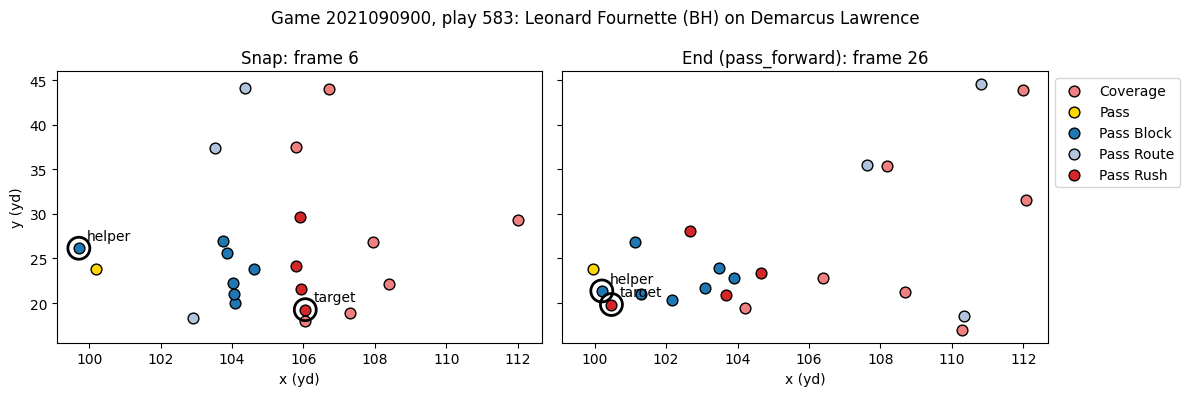

In [12]:
# Reference play 583 if it survived selection, otherwise the first candidate
_ref = candidates.query("gameId == 2021090900 and playId == 583")
demo_cand = (_ref if not _ref.empty else candidates).iloc[0]
DEMO_GAME, DEMO_PLAY = int(demo_cand["gameId"]), int(demo_cand["playId"])

demo_track, demo_meta = prepare_play_tracking(DEMO_GAME, DEMO_PLAY)
check_play_track(demo_track, demo_meta)
display(pd.Series(demo_meta))
display(demo_track.drop_duplicates("nflId")["pff_role"].value_counts())

# Snap vs end-of-window positions, coloured by role, with helper/target outlined
ROLE_COLORS = {"Pass": "gold", "Pass Block": "tab:blue", "Pass Route": "lightsteelblue",
               "Pass Rush": "tab:red", "Coverage": "lightcoral"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, frame, title in [(axes[0], demo_meta["snap_frame"], "Snap"),
                         (axes[1], demo_meta["end_frame"], f"End ({demo_meta['end_event']})")]:
    snap_df = demo_track[demo_track["frameId"] == frame]
    for role, grp in snap_df.groupby("pff_role"):
        ax.scatter(grp["x"], grp["y"], c=ROLE_COLORS.get(role, "grey"), label=role, s=60, edgecolors="k")
    for pid, lab in [(demo_cand["helper_id"], "helper"), (demo_cand["target_id"], "target")]:
        p = snap_df[snap_df["nflId"] == pid]
        ax.scatter(p["x"], p["y"], s=250, facecolors="none", edgecolors="black", linewidths=2)
        ax.annotate(lab, (p["x"].iloc[0], p["y"].iloc[0]), xytext=(6, 6), textcoords="offset points")
    ax.set_title(f"{title}: frame {frame}")
    ax.set_xlabel("x (yd)")
axes[0].set_ylabel("y (yd)")
axes[1].legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.suptitle(f"Game {DEMO_GAME}, play {DEMO_PLAY}: {demo_cand['helper_name']} ({demo_cand['pff_blockType']}) "
             f"on {demo_cand['target_name']}")
plt.tight_layout()
plt.show()


## 4. Defender threat

For each pass rusher `i` at frame `t`:
- `d_i(t)`: Euclidean distance to the QB in the same frame (yd)
- `c_i(t) = max(0, -(d_i(t) - d_i(t - 3)) / 0.3)`: closing speed over 3 frames (yd/s); moving away counts as 0
- `T_i(t) = c_i(t) / (1 + d_i(t))`: threat proxy (1/s), high when a rusher is both close and closing fast

Distance is measured *relative to the QB*, so a QB drifting in the pocket changes threat too. The first 3 frames of each rusher have no closing speed (NaN).


In [13]:
def calculate_threat(track, lag=CLOSE_LAG, dt=DT):
    """Add qb_x, qb_y, distance_to_qb, closing_speed, threat_score. Values are NaN for non-rushers."""
    out = track.copy()

    # QB position in the same frame
    qb = out.loc[out["pff_role"] == "Pass", ["frameId", "x", "y"]].rename(columns={"x": "qb_x", "y": "qb_y"})
    out = out.merge(qb, on="frameId", how="left")

    is_rusher = out["pff_role"].eq("Pass Rush")
    out["distance_to_qb"] = np.hypot(out["x"] - out["qb_x"], out["y"] - out["qb_y"]).where(is_rusher)

    # Closing speed: drop in distance over `lag` frames, per rusher, in frame order
    out = out.sort_values(["nflId", "frameId"])
    delta = out.groupby("nflId")["distance_to_qb"].diff(lag)
    out["closing_speed"] = (-delta / (lag * dt)).clip(lower=0)      # NaN stays NaN

    out["threat_score"] = out["closing_speed"] / (1 + out["distance_to_qb"])
    return out.sort_values(["frameId", "nflId"]).reset_index(drop=True)


In [14]:
def _synthetic_track(paths, n_frames=10):
    """paths: {nflId: (pff_role, f(frame) -> (x, y))}. Returns a minimal track for calculate_threat."""
    rows = [dict(frameId=f, nflId=pid, pff_role=role, x=fn(f)[0], y=fn(f)[1])
            for f in range(1, n_frames + 1) for pid, (role, fn) in paths.items()]
    return pd.DataFrame(rows)

# QB fixed at the origin
_th = calculate_threat(_synthetic_track({
    1:  ("Pass",       lambda f: (0.0, 0.0)),
    10: ("Pass Rush",  lambda f: (5.0, 0.0)),               # stationary
    11: ("Pass Rush",  lambda f: (20.0 - (f - 1), 0.0)),    # closes 1 yd/frame = 10 yd/s
    12: ("Pass Rush",  lambda f: (5.0 + (f - 1), 0.0)),     # moving away
    13: ("Pass Rush",  lambda f: (3.0, 4.0)),               # 3-4-5 triangle
    20: ("Pass Block", lambda f: (1.0, 0.0)),               # non-rusher
}))
_r = lambda pid, f: _th[(_th["nflId"] == pid) & (_th["frameId"] == f)].iloc[0]

assert np.isclose(_r(13, 5)["distance_to_qb"], 5.0)
assert _r(10, 5)["closing_speed"] == 0 and _r(10, 5)["threat_score"] == 0
assert _r(12, 5)["closing_speed"] == 0                                   # moving away is not threat
assert np.isclose(_r(11, 4)["closing_speed"], 10.0)                      # d: 20 -> 17 over 0.3 s
assert np.isclose(_r(11, 4)["threat_score"], 10.0 / (1 + 17.0))
for pid in (10, 11, 12, 13):                                             # first CLOSE_LAG frames undefined
    assert _th[_th["nflId"] == pid]["closing_speed"].isna().sum() == CLOSE_LAG
assert _th.loc[_th["nflId"] == 20, ["distance_to_qb", "closing_speed", "threat_score"]].isna().all().all()

# QB and rusher moving together: constant separation, so zero closing speed
_th2 = calculate_threat(_synthetic_track({
    1:  ("Pass",      lambda f: (float(f), 0.0)),
    10: ("Pass Rush", lambda f: (float(f) + 5.0, 0.0)),
}))
assert (_th2["closing_speed"].dropna() == 0).all()
print("Synthetic threat tests passed.")


Synthetic threat tests passed.


,,start_dist,min_dist,max_closing,max_threat,mean_threat
nflId,displayName,,,,,
41263,Demarcus Lawrence,7.421,4.013,2.806,0.529,0.275
42403,Randy Gregory,8.196,5.052,3.050,0.426,0.240
41363,Brent Urban,6.178,4.711,1.236,0.191,0.123
44955,Carlos Watkins,5.633,4.722,0.813,0.132,0.079


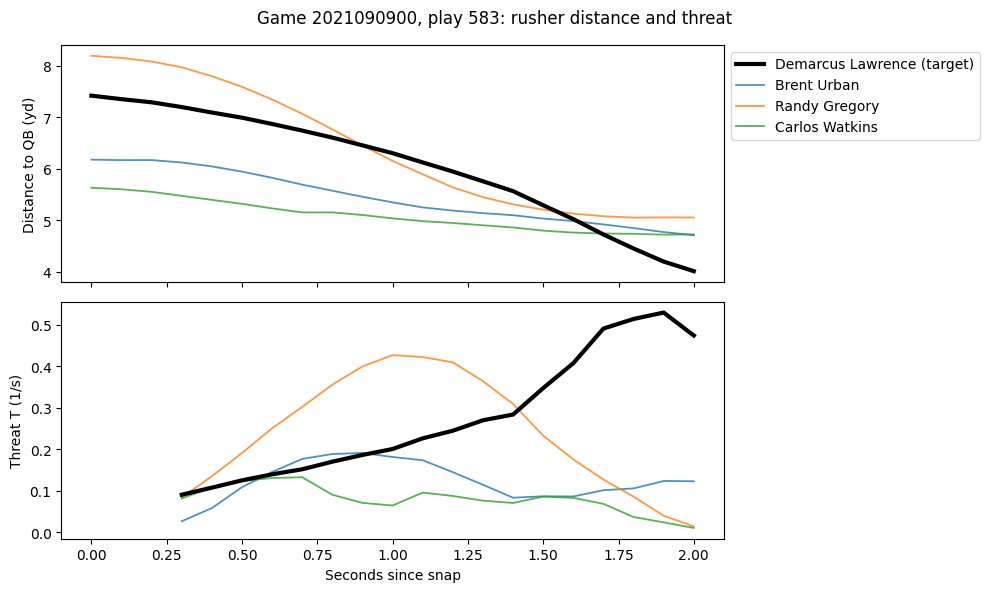

Task 4 checks passed.


In [15]:
demo_threat = calculate_threat(demo_track)
rush = demo_threat[demo_threat["pff_role"] == "Pass Rush"]

# Real-data checks
assert rush["distance_to_qb"].notna().all(), "rusher missing QB distance"
assert (rush["threat_score"].dropna() >= 0).all()
assert (rush.groupby("nflId")["closing_speed"].apply(lambda s: s.isna().sum()) == CLOSE_LAG).all()
assert demo_threat.loc[demo_threat["pff_role"] != "Pass Rush", "threat_score"].isna().all()
_fast = rush["closing_speed"].max()
if _fast > 15:
    print(f"Warning: closing speed {_fast:.1f} yd/s is implausibly high; inspect tracking.")

# Per-rusher summary
display(rush.groupby(["nflId", "displayName"]).agg(
    start_dist=("distance_to_qb", "first"), min_dist=("distance_to_qb", "min"),
    max_closing=("closing_speed", "max"), max_threat=("threat_score", "max"),
    mean_threat=("threat_score", "mean"),
).round(3).sort_values("max_threat", ascending=False))

# Distance and threat over time; target in bold black
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for pid, g in rush.groupby("nflId"):
    is_target = pid == demo_cand["target_id"]
    style = dict(lw=3, color="black", zorder=3) if is_target else dict(lw=1.3, alpha=0.8)
    label = g["displayName"].iloc[0] + (" (target)" if is_target else "")
    ax1.plot(g["t"], g["distance_to_qb"], label=label, **style)
    ax2.plot(g["t"], g["threat_score"], **style)
ax1.set_ylabel("Distance to QB (yd)")
ax2.set_ylabel("Threat T (1/s)")
ax2.set_xlabel("Seconds since snap")
ax1.legend(loc="upper left", bbox_to_anchor=(1, 1))
fig.suptitle(f"Game {DEMO_GAME}, play {DEMO_PLAY}: rusher distance and threat")
plt.tight_layout()
plt.show()
print("Task 4 checks passed.")


## 5. Detect the help moment

PFF tells us *who* helped *whom*, not *when*. We infer the moment as the first frame of a run of at least `MIN_SUSTAIN` consecutive frames in which the helper is within `HELP_DIST` yards of the target, **after** the pair has been apart at least once. Proximity is not proof of contact, so every event is labelled `inferred`, or `manual` when set in `MANUAL_EVENT_FRAMES`.

Quality labels:
- `ok`: full before and after windows fit inside snap → release
- `too_early`: not enough frames before the event, including the closing-speed lag
- `too_late`: not enough frames after the event before release
- `close_at_snap`: the pair was close from the snap and never separated; there is no distinct help moment
- `no_contact`: they were never within `HELP_DIST` for `MIN_SUSTAIN` frames
- `player_missing`: the helper or target is absent from tracking


In [16]:
def help_distance(track, helper_id, target_id):
    """Helper-target distance per frame (Series indexed by frameId), or None if either is missing."""
    sub = track[track["nflId"].isin([helper_id, target_id])]
    pos = sub.pivot(index="frameId", columns="nflId", values=["x", "y"])
    if helper_id not in pos["x"].columns or target_id not in pos["x"].columns:
        return None
    return np.hypot(pos["x"][helper_id] - pos["x"][target_id],
                    pos["y"][helper_id] - pos["y"][target_id]).rename("help_dist")

def find_help_onset(dist, threshold=HELP_DIST, min_sustain=MIN_SUSTAIN):
    """Return (frame, None) for the first sustained close run preceded by an apart run,
    (frame, 'truncated') for a close run cut off by release before reaching min_sustain,
    or (None, reason) where reason is 'close_at_snap' or 'no_contact'."""
    close = (dist <= threshold).to_numpy()
    frames = dist.index.to_numpy()

    # Split into alternating runs: (is_close, start_index, length)
    runs, i = [], 0
    while i < len(close):
        j = i
        while j < len(close) and close[j] == close[i]:
            j += 1
        runs.append((bool(close[i]), i, j - i))
        i = j

    # 1. First sustained close run that follows an apart run
    for k, (is_close, start, length) in enumerate(runs):
        if is_close and length >= min_sustain and k > 0:
            return int(frames[start]), None

    # 2. Fallbacks, checked only after the loop has finished
    last_close, last_start, last_len = runs[-1] if runs else (False, 0, 0)
    if last_close and len(runs) > 1 and last_len < min_sustain:
        return int(frames[last_start]), "truncated"     # late arrival cut off by release
    if runs and runs[0][0] and runs[0][2] >= min_sustain:
        return None, "close_at_snap"
    return None, "no_contact"

def detect_help_event(track, meta, helper_id, target_id, manual=None, help_dist=HELP_DIST):
    """Infer (or look up) the help frame and assess whether before/after windows fit.
    help_dist overrides the proximity threshold (used for the sensitivity check)."""
    manual = MANUAL_EVENT_FRAMES if manual is None else manual
    helper_id, target_id = int(helper_id), int(target_id)
    snap, end = meta["snap_frame"], meta["end_frame"]
    out = dict(gameId=meta["gameId"], playId=meta["playId"], helper_id=helper_id, target_id=target_id,
               frame=None, t=None, method=None, quality=None, min_help_dist=np.nan, dist_at_event=np.nan)

    dist = help_distance(track, helper_id, target_id)
    if dist is None:
        return {**out, "quality": "player_missing"}
    out["min_help_dist"] = float(dist.min())

    key = (meta["gameId"], meta["playId"], helper_id)
    if key in manual:
        frame, reason, out["method"] = int(manual[key]), None, "manual"
        assert snap <= frame <= end, f"manual frame {frame} outside play window {snap}-{end}"
    else:
        frame, reason = find_help_onset(dist, threshold=help_dist)   # threshold passed explicitly
        out["method"] = "inferred"

    if frame is None:
        return {**out, "quality": reason}

    # Before window needs CLOSE_LAG frames of history; after window must end by release
    if frame < snap + CLOSE_LAG + GAP + WINDOW:
        quality = "too_early"
    elif frame + GAP + WINDOW > end:
        quality = "too_late"
    else:
        quality = "ok"
    return {**out, "frame": frame, "t": (frame - snap) / FPS, "quality": quality,
            "dist_at_event": float(dist.loc[frame])}




In [17]:
def _pair_track(helper_x, n_frames=30):
    """Target fixed at (0, 0); helper at (helper_x(f), 0). Distance = |helper_x(f)|."""
    rows = []
    for f in range(1, n_frames + 1):
        rows += [dict(frameId=f, nflId=10, x=0.0, y=0.0), dict(frameId=f, nflId=20, x=float(helper_x(f)), y=0.0)]
    return pd.DataFrame(rows)

_m = dict(gameId=1, playId=1, snap_frame=1, end_frame=30)
_ev = lambda fx, **kw: detect_help_event(_pair_track(fx), _m, 20, 10, manual=kw.get("manual", {}))

# Converges at frame 12 and stays close -> event 12, windows fit
e = _ev(lambda f: 5 if f < 12 else 1.5)
assert (e["frame"], e["quality"], e["method"]) == (12, "ok", "inferred")

# Never close -> no event
assert _ev(lambda f: 5)["quality"] == "no_contact"

# Single close frame is not sustained -> no event
assert _ev(lambda f: 1.5 if f == 12 else 5)["quality"] == "no_contact"

# Brief 2-frame touch, then a sustained run from 20 -> event 20
assert _ev(lambda f: 1.5 if f in (12, 13) or f >= 20 else 5)["frame"] == 20

# Close from the snap and never apart -> close_at_snap
assert _ev(lambda f: 1.5)["quality"] == "close_at_snap"

# Close at snap, separates, re-engages at 10 -> event 10
assert _ev(lambda f: 5 if 4 <= f <= 9 else 1.5)["frame"] == 10

# Window feasibility: too early (needs frame >= 1+3+1+4 = 9) and too late (needs frame + 5 <= 30)
assert _ev(lambda f: 5 if f < 4 else 1.5)["quality"] == "too_early"
assert _ev(lambda f: 5 if f < 27 else 1.5)["quality"] == "too_late"

# Manual override wins over inference
e = _ev(lambda f: 5, manual={(1, 1, 20): 15})
assert (e["frame"], e["method"], e["quality"]) == (15, "manual", "ok")
print("Synthetic detection tests passed.")

# Arrives in the last 2 frames before release -> late arrival, not no_contact
e = _ev(lambda f: 5 if f < 29 else 1.5)
assert (e["frame"], e["quality"]) == (29, "too_late")



Synthetic detection tests passed.


gameId           2021090900
playId                  583
helper_id             44816
target_id             41263
frame                    25
t                       1.9
method             inferred
quality            too_late
min_help_dist      1.543794
dist_at_event       1.92346
dtype: object

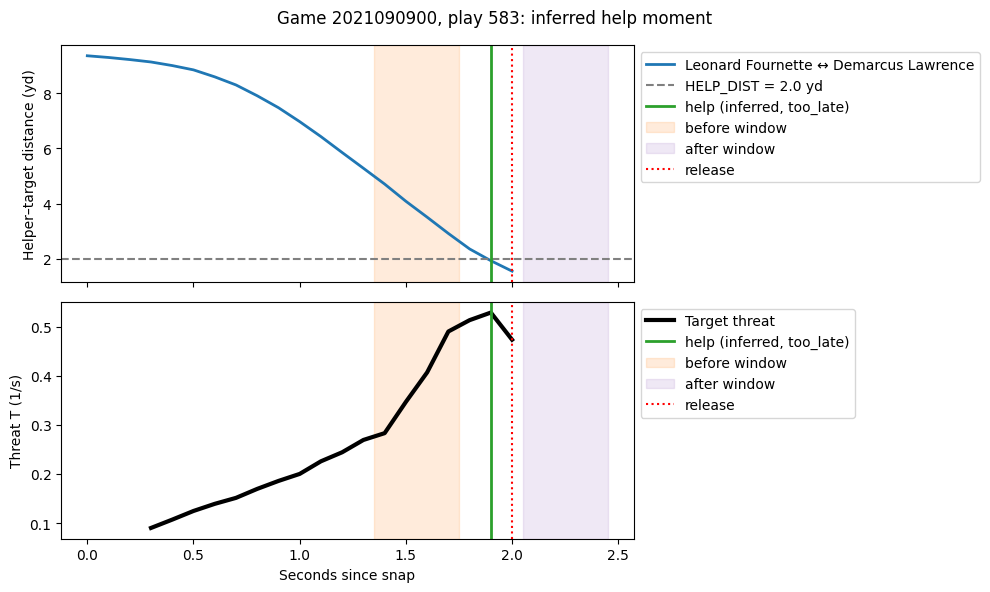

In [18]:
demo_event = detect_help_event(demo_track, demo_meta, demo_cand["helper_id"], demo_cand["target_id"])
display(pd.Series(demo_event))
demo_dist = help_distance(demo_track, int(demo_cand["helper_id"]), int(demo_cand["target_id"]))
_t = (demo_dist.index - demo_meta["snap_frame"]) / FPS

tgt = demo_threat[demo_threat["nflId"] == demo_cand["target_id"]]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax1.plot(_t, demo_dist.values, color="tab:blue", lw=2, label=f"{demo_cand['helper_name']} ↔ {demo_cand['target_name']}")
ax1.axhline(HELP_DIST, color="grey", ls="--", label=f"HELP_DIST = {HELP_DIST} yd")
ax1.set_ylabel("Helper–target distance (yd)")
ax2.plot(tgt["t"], tgt["threat_score"], color="black", lw=3, label="Target threat")
ax2.set_ylabel("Threat T (1/s)")
ax2.set_xlabel("Seconds since snap")

for ax in (ax1, ax2):
    if demo_event["frame"] is not None:
        ax.axvline(demo_event["t"], color="tab:green", lw=2, label=f"help ({demo_event['method']}, {demo_event['quality']})")
        # Before / after windows in seconds since snap
        e = demo_event["t"]
        half = 0.5 / FPS  # half a frame, so each band covers its frames symmetrically
        ax.axvspan(e - (GAP + WINDOW) / FPS - half, e - (GAP + 1) / FPS + half,
                   color="tab:orange", alpha=0.15, label="before window")
        ax.axvspan(e + (GAP + 1) / FPS - half, e + (GAP + WINDOW) / FPS + half,
                   color="tab:purple", alpha=0.15, label="after window")
        # e = demo_event["t"]
        # ax.axvspan(e - (GAP + WINDOW) / FPS, e - GAP / FPS, color="tab:orange", alpha=0.15, label="before window")
        # ax.axvspan(e + (GAP + 1) / FPS, e + (GAP + WINDOW) / FPS, color="tab:purple", alpha=0.15, label="after window")
    ax.axvline((demo_meta["end_frame"] - demo_meta["snap_frame"]) / FPS, color="red", ls=":", label="release")
ax1.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax2.legend(loc="upper left", bbox_to_anchor=(1, 1))
fig.suptitle(f"Game {DEMO_GAME}, play {DEMO_PLAY}: inferred help moment")
plt.tight_layout()
plt.show()


In [19]:
_events = []
for c in candidates.itertuples(index=False):
    try:
        _trk, _m = prepare_play_tracking(int(c.gameId), int(c.playId))
        _events.append(detect_help_event(_trk, _m, c.helper_id, c.target_id))
    except (ValueError, AssertionError) as err:
        _events.append(dict(gameId=c.gameId, playId=c.playId, helper_id=c.helper_id,
                            target_id=c.target_id, quality=f"error: {err}"))
help_events = pd.DataFrame(_events).merge(
    candidates[KEYS + ["helper_id", "pff_blockType", "n_other_blockers_on_target"]], on=KEYS + ["helper_id"])

# Checks
VALID_Q = {"ok", "too_early", "too_late", "close_at_snap", "no_contact", "player_missing"}
assert len(help_events) == len(candidates)
assert help_events["quality"].isin(VALID_Q).mean() > 0.9, help_events["quality"].value_counts()
_ok = help_events[help_events["quality"] == "ok"]
assert (_ok["dist_at_event"] <= HELP_DIST).all() or (_ok["method"] == "manual").any()

print(f"usable (ok) events: {len(_ok)} of {len(help_events)}")
display(pd.crosstab(help_events["quality"], help_events["pff_blockType"], margins=True))
display(_ok["t"].describe().round(2))
print("Task 5 checks passed.")


usable (ok) events: 46 of 281


pff_blockType,BH,PT,All
quality,,,
close_at_snap,0,108,108
error: no ball_snap event on this play,0,2,2
no_contact,3,4,7
ok,15,31,46
too_early,1,106,107
too_late,7,4,11
All,26,255,281


count    46.00
mean      1.38
std       0.45
min       0.80
25%       1.00
50%       1.30
75%       1.70
max       2.50
Name: t, dtype: float64

Task 5 checks passed.


## 6. Help Ripple Index

For a usable help event at frame `e`, with before frames `e-5 … e-2` and after frames `e+2 … e+5` (`GAP = 1` transition frame excluded on each side):

- `B = mean T_target(before) − mean T_target(after)`: positive means the target became less threatening
- `C = Σ_{other rushers} max(0, mean T_j(after) − mean T_j(before))`: added threat elsewhere
- `HRI = B − C` (1/s)

Each rusher's **contribution** to HRI is listed separately (the target contributes `+B`, each other rusher contributes `−max(0, Δ)`), so the score always adds up from visible parts. `cost_per_other_rusher` and `net_other_change` (signed, without the max) are reported for context, since `C` grows with the number of rushers.


In [20]:
def event_windows(frame, gap=GAP, window=WINDOW):
    """Frame lists for the before and after windows around an event frame."""
    before = list(range(frame - gap - window, frame - gap))
    after = list(range(frame + gap + 1, frame + gap + window + 1))
    return before, after

def calculate_help_ripple_index(threat_track, event):
    """Return (summary dict, per-rusher DataFrame) for one help event with quality 'ok'."""
    if event.get("quality") != "ok":
        raise ValueError(f"event quality is {event.get('quality')!r}; only 'ok' events can be scored")

    frame, target_id = int(event["frame"]), int(event["target_id"])
    before, after = event_windows(frame)
    rush = threat_track[threat_track["pff_role"] == "Pass Rush"]
    win = rush[rush["frameId"].isin(before + after)].copy()

    # Every rusher must have a defined threat on every window frame
    assert win["threat_score"].notna().all(), "NaN threat inside a window"
    assert (win.groupby("nflId").size() == len(before) + len(after)).all(), "rusher missing window frames"

    win["window"] = np.where(win["frameId"].isin(before), "before", "after")
    per = win.pivot_table(index="nflId", columns="window", values="threat_score", aggfunc="mean")[["before", "after"]]
    assert target_id in per.index, "target is not a rusher in this track"

    per["delta"] = per["after"] - per["before"]
    per["is_target"] = per.index == target_id
    # Contribution to HRI: target adds B = -delta; others subtract any increase
    per["contribution"] = np.where(per["is_target"], -per["delta"], -per["delta"].clip(lower=0))

    others = per[~per["is_target"]]
    B = float(-per.loc[target_id, "delta"])
    C = float(others["delta"].clip(lower=0).sum())

    summary = {k: event[k] for k in ["gameId", "playId", "helper_id", "target_id", "frame", "t", "method"]}
    summary.update(
        target_before=float(per.loc[target_id, "before"]), target_after=float(per.loc[target_id, "after"]),
        target_benefit=B, other_rusher_cost=C, help_ripple_index=B - C,
        n_other_rushers=len(others),
        cost_per_other_rusher=C / len(others) if len(others) else np.nan,
        net_other_change=float(others["delta"].sum()),
    )
    return summary, per.reset_index()


In [21]:
def _threat_track(series, n=20):
    """series: {nflId: (pff_role, f(frame) -> threat)}."""
    return pd.DataFrame([dict(frameId=f, nflId=pid, pff_role=role, threat_score=fn(f))
                         for pid, (role, fn) in series.items() for f in range(1, n + 1)])

_EV = dict(gameId=1, playId=1, helper_id=20, target_id=10, frame=10, t=0.9, method="inferred", quality="ok")

# Windows for e=10: before 5..8, after 12..15; frames 9, 10, 11 must be ignored (set to 99)
assert event_windows(10) == ([5, 6, 7, 8], [12, 13, 14, 15])
_tt = _threat_track({
    1:  ("Pass",      lambda f: np.nan),                                            # QB ignored
    10: ("Pass Rush", lambda f: 99 if 9 <= f <= 11 else (0.16 if f < 10 else 0.08)),  # target: -0.08
    11: ("Pass Rush", lambda f: 99 if 9 <= f <= 11 else (0.05 if f < 10 else 0.10)),  # other: +0.05
    12: ("Pass Rush", lambda f: 99 if 9 <= f <= 11 else (0.10 if f < 10 else 0.07)),  # other: -0.03 (no cost)
})
s, per = calculate_help_ripple_index(_tt, _EV)
assert np.isclose(s["target_benefit"], 0.08)
assert np.isclose(s["other_rusher_cost"], 0.05)
assert np.isclose(s["help_ripple_index"], 0.03)
assert np.isclose(per["contribution"].sum(), s["help_ripple_index"])     # score adds up from parts
assert s["n_other_rushers"] == 2 and np.isclose(s["cost_per_other_rusher"], 0.025)
assert np.isclose(s["net_other_change"], 0.02)                            # +0.05 - 0.03, signed

# No change anywhere gives HRI = 0
s0, _ = calculate_help_ripple_index(_threat_track({10: ("Pass Rush", lambda f: 0.1),
                                                    11: ("Pass Rush", lambda f: 0.2)}), _EV)
assert s0["help_ripple_index"] == 0

# Unusable events are refused
try:
    calculate_help_ripple_index(_tt, {**_EV, "quality": "too_late"})
    raise AssertionError("expected ValueError")
except ValueError:
    pass
print("Synthetic HRI tests passed.")


Synthetic HRI tests passed.


In [22]:
# Prefer a BH event, then events where PFF lists another blocker on the same target (clearer help)
ok_events = help_events[help_events["quality"] == "ok"]
pick = ok_events.sort_values(["pff_blockType", "n_other_blockers_on_target"], ascending=[True, False]).iloc[0]
HRI_GAME, HRI_PLAY, HRI_HELPER = int(pick["gameId"]), int(pick["playId"]), int(pick["helper_id"])
hri_cand = candidates[(candidates["gameId"] == HRI_GAME) & (candidates["playId"] == HRI_PLAY)
                      & (candidates["helper_id"] == HRI_HELPER)].iloc[0]

hri_track, hri_meta = prepare_play_tracking(HRI_GAME, HRI_PLAY)
hri_threat = calculate_threat(hri_track)
hri_event = detect_help_event(hri_track, hri_meta, hri_cand["helper_id"], hri_cand["target_id"])
hri_summary, hri_per = calculate_help_ripple_index(hri_threat, hri_event)

# Checks
assert np.isclose(hri_summary["help_ripple_index"],
                  hri_summary["target_benefit"] - hri_summary["other_rusher_cost"])
assert np.isclose(hri_per["contribution"].sum(), hri_summary["help_ripple_index"])

# Breakdown table with names
names = players.set_index("nflId")["displayName"]
hri_per["rusher"] = hri_per["nflId"].map(names) + np.where(hri_per["is_target"], " (target)", "")
display(hri_per[["rusher", "before", "after", "delta", "contribution"]].round(3)
        .sort_values("contribution"))

print(f"Game {HRI_GAME}, play {HRI_PLAY}: {hri_cand['helper_name']} ({hri_cand['pff_blockType']}) "
      f"on {hri_cand['target_name']}, help at t = {hri_event['t']:.1f} s ({hri_event['method']})")
print(f"  B (target benefit)      = {hri_summary['target_benefit']:+.3f}")
print(f"  C (other-rusher cost)   = {hri_summary['other_rusher_cost']:+.3f}  "
      f"({hri_summary['n_other_rushers']} others, {hri_summary['cost_per_other_rusher']:.3f} each)")
print(f"  HRI = B - C             = {hri_summary['help_ripple_index']:+.3f} 1/s")
print(f"  PFF context: target hit/hurry/sack = {hri_cand['target_hit']:.0f}/{hri_cand['target_hurry']:.0f}/"
      f"{hri_cand['target_sack']:.0f}, play pressure = {hri_cand['play_hit']:.0f}/{hri_cand['play_hurry']:.0f}/"
      f"{hri_cand['play_sack']:.0f}, result = {hri_cand['passResult']}")


window,rusher,before,after,delta,contribution
0,Demarcus Lawrence,0.000,0.000,0.000,-0.000
1,Randy Gregory,0.288,0.124,-0.164,-0.000
2,Micah Parsons (target),0.195,0.128,-0.067,0.067


Game 2021090900, play 2441: Giovani Bernard (BH) on Micah Parsons, help at t = 1.2 s (inferred)
  B (target benefit)      = +0.067
  C (other-rusher cost)   = +0.000  (2 others, 0.000 each)
  HRI = B - C             = +0.067 1/s
  PFF context: target hit/hurry/sack = 0/0/0, play pressure = 0/0/0, result = IN


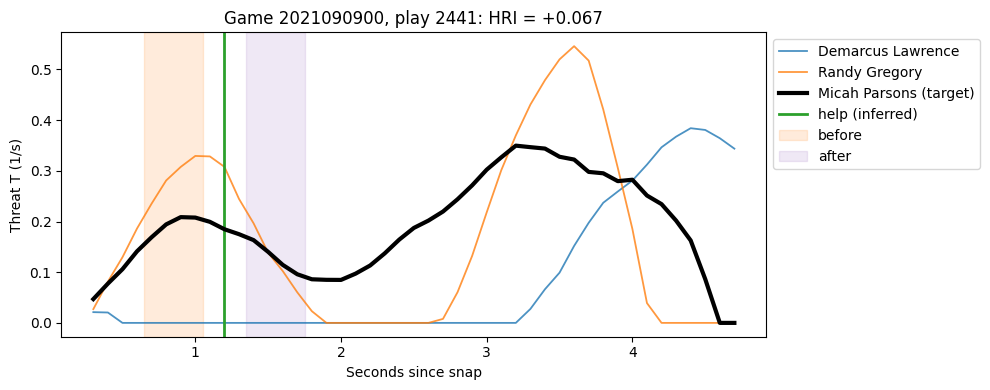

Task 6 checks passed.


In [23]:
before, after = event_windows(hri_event["frame"])
to_t = lambda f: (f - hri_meta["snap_frame"]) / FPS
half = 0.5 / FPS
rush = hri_threat[hri_threat["pff_role"] == "Pass Rush"]

fig, ax = plt.subplots(figsize=(10, 4))
for pid, g in rush.groupby("nflId"):
    is_target = pid == hri_cand["target_id"]
    style = dict(lw=3, color="black", zorder=3) if is_target else dict(lw=1.3, alpha=0.8)
    ax.plot(g["t"], g["threat_score"], label=names.get(pid, pid) + (" (target)" if is_target else ""), **style)
ax.axvline(hri_event["t"], color="tab:green", lw=2, label="help (inferred)")
ax.axvspan(to_t(before[0]) - half, to_t(before[-1]) + half, color="tab:orange", alpha=0.15, label="before")
ax.axvspan(to_t(after[0]) - half, to_t(after[-1]) + half, color="tab:purple", alpha=0.15, label="after")
ax.set_xlabel("Seconds since snap")
ax.set_ylabel("Threat T (1/s)")
ax.set_title(f"Game {HRI_GAME}, play {HRI_PLAY}: HRI = {hri_summary['help_ripple_index']:+.3f}")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()
print("Task 6 checks passed.")


## 7. Score all candidates and pick featured plays

Every candidate is scored at `HELP_DIST` = 1.5, 2.0 and 2.5 yd. Each scored event is given a pattern:
- **clean gain**: target threat fell, no other rusher rose (`B > 0`, `C = 0`)
- **trade-off, net gain**: target fell, others rose, but by less (`B > C > 0`)
- **hidden cost**: target fell, others rose by more (`C ≥ B > 0`)
- **no local benefit**: target threat did not fall (`B ≤ 0`)

The featured positive play is a *trade-off, net gain* and the featured negative play is a *hidden cost*. Picks must have a real release or sack event and a play window of at most `MAX_PLAY_SECONDS` (longer windows are usually extended or broken plays with unrepresentative threat spikes). Among those, picks prefer events that are the only scored event on their play and whose sign is the same at all three thresholds.


In [24]:
_PLAY_CACHE = {}

def get_play(game_id, play_id):
    """Prepared track, meta and threat for one play, computed once."""
    key = (game_id, play_id)
    if key not in _PLAY_CACHE:
        trk, meta = prepare_play_tracking(game_id, play_id)
        check_play_track(trk, meta)
        _PLAY_CACHE[key] = (trk, meta, calculate_threat(trk))
    return _PLAY_CACHE[key]

CAND_COLS = KEYS + ["helper_id", "helper_name", "helper_pos", "pff_blockType", "target_id", "target_name",
                    "n_other_blockers_on_target", "n_rushers", "target_hit", "target_hurry", "target_sack",
                    "play_hit", "play_hurry", "play_sack", "passResult", "label_source"]
EVENT_COLS = ["frame", "t", "method", "quality", "min_help_dist", "dist_at_event"]
SUMMARY_COLS = ["target_before", "target_after", "target_benefit", "other_rusher_cost", "help_ripple_index",
                "n_other_rushers", "cost_per_other_rusher", "net_other_change"]

def classify_pattern(df):
    B, C = df["target_benefit"], df["other_rusher_cost"]
    return pd.Series(np.select(
        [B.isna(), (B > 0) & (C == 0), (B > 0) & (C > 0) & (B > C), (B > 0) & (C >= B)],
        [None, "clean gain", "trade-off, net gain", "hidden cost"],
        default="no local benefit"), index=df.index)

def score_candidates(cands, help_dist=HELP_DIST):
    """One row per candidate: detection result, and HRI components when the event is usable."""
    rows = []
    for c in cands.itertuples(index=False):
        base = {col: getattr(c, col) for col in CAND_COLS}
        try:
            trk, meta, thr = get_play(int(c.gameId), int(c.playId))
        except (ValueError, AssertionError) as err:
            rows.append({**base, "status": f"error: {err}"})
            continue
        ev = detect_help_event(trk, meta, c.helper_id, c.target_id, help_dist=help_dist)
        row = {**base, **{k: ev[k] for k in EVENT_COLS},
               "play_seconds": (meta["end_frame"] - meta["snap_frame"]) / FPS, "end_event": meta["end_event"]}
        if ev["quality"] == "ok":
            summary, _ = calculate_help_ripple_index(thr, ev)
            row.update({k: summary[k] for k in SUMMARY_COLS}, status="scored")
        else:
            row["status"] = ev["quality"]
        rows.append(row)

    out = pd.DataFrame(rows)
    for col in SUMMARY_COLS:                       # keep columns even if nothing scored
        out[col] = out.get(col, np.nan)
    out["pattern"] = classify_pattern(out)
    out["n_scored_on_play"] = out.groupby(KEYS)["status"].transform(lambda s: s.eq("scored").sum())
    return out


In [25]:
MAX_PLAY_SECONDS = 5.0   # normal dropbacks are ~2.5-3.5 s; longer windows are usually broken plays

def select_featured(scores, n=3, max_play_seconds=MAX_PLAY_SECONDS):
    """Shortlists (positive, negative) of up to n events each, best first."""
    s = scores[(scores["status"] == "scored")
               & scores["end_event"].notna()
               & (scores["play_seconds"] <= max_play_seconds)].copy()
    s["overlap"] = s["n_scored_on_play"] > 1

    pos = s[s["pattern"] == "trade-off, net gain"]
    if pos.empty:
        pos = s[s["help_ripple_index"] > 0]
    neg = s[s["pattern"] == "hidden cost"]
    if neg.empty:
        neg = s[s["help_ripple_index"] < 0]

    # Prefer: no overlapping event on the play, sign stable across thresholds, then strongest score
    pos = pos.sort_values(["overlap", "sign_stable", "help_ripple_index"], ascending=[True, False, False])
    neg = neg.sort_values(["overlap", "sign_stable", "help_ripple_index"], ascending=[True, False, True])
    return pos.head(n), neg.head(n)

# Synthetic: one candidate per pattern, plus traps (overlap, unstable, unscored, too long, no end event)
def _cand(id, B, C, n_on_play=1, stable=True, end="pass_forward", secs=3.0):
    return dict(id=id, target_benefit=B, other_rusher_cost=C, n_scored_on_play=n_on_play,
                sign_stable=stable, end_event=end, play_seconds=secs)

_s = pd.DataFrame([
    _cand("tradeoff_ok",          0.10, 0.04),
    _cand("tradeoff_big_overlap", 0.30, 0.05, n_on_play=2),
    _cand("tradeoff_unstable",    0.20, 0.05, stable=False),
    _cand("tradeoff_long",        0.90, 0.10, secs=9.6),       # excluded: play too long
    _cand("tradeoff_no_end",      0.80, 0.10, end=None),       # excluded: no release/sack event
    _cand("clean",                0.10, 0.00),
    _cand("hidden_ok",            0.05, 0.12),
    _cand("no_benefit",          -0.05, 0.20),
    _cand("unscored",           np.nan, np.nan, n_on_play=0, stable=False),
])
_s["help_ripple_index"] = _s["target_benefit"] - _s["other_rusher_cost"]
_s["status"] = np.where(_s["target_benefit"].isna(), "too_late", "scored")
_s["pattern"] = classify_pattern(_s)

assert _s.set_index("id")["pattern"].to_dict() == {
    "tradeoff_ok": "trade-off, net gain", "tradeoff_big_overlap": "trade-off, net gain",
    "tradeoff_unstable": "trade-off, net gain", "tradeoff_long": "trade-off, net gain",
    "tradeoff_no_end": "trade-off, net gain", "clean": "clean gain", "hidden_ok": "hidden cost",
    "no_benefit": "no local benefit", "unscored": None}
_pos, _neg = select_featured(_s)
assert _pos["id"].tolist() == ["tradeoff_ok", "tradeoff_unstable", "tradeoff_big_overlap"]
assert _neg["id"].tolist() == ["hidden_ok"]          # 'no_benefit' is not a hidden cost
print("Synthetic selection tests passed.")


Synthetic selection tests passed.


In [26]:
SENSITIVITY_DISTS = [1.5, 2.0, 2.5]
_runs = {d: score_candidates(candidates, help_dist=d) for d in SENSITIVITY_DISTS}

scores = _runs[HELP_DIST].copy()
for d in SENSITIVITY_DISTS:
    if d != HELP_DIST:
        scores = scores.merge(_runs[d][KEYS + ["helper_id", "help_ripple_index"]]
                              .rename(columns={"help_ripple_index": f"hri_at_{d}"}),
                              on=KEYS + ["helper_id"], how="left")
_alt = [f"hri_at_{d}" for d in SENSITIVITY_DISTS if d != HELP_DIST]
_sign = np.sign(scores["help_ripple_index"])
scores["sign_stable"] = scores[_alt].notna().all(axis=1) & np.sign(scores[_alt]).eq(_sign, axis=0).all(axis=1)

pos_short, neg_short = select_featured(scores)

# Manual override if visual review rejects a pick: (gameId, playId, helper_id) or None
FEATURED_OVERRIDE = {"positive": None, "negative": None}

def _pick(short, key):
    if FEATURED_OVERRIDE[key] is not None:
        g, p, h = FEATURED_OVERRIDE[key]
        return scores[(scores["gameId"] == g) & (scores["playId"] == p) & (scores["helper_id"] == h)].iloc[0]
    return short.iloc[0]

FEATURED = {"positive": _pick(pos_short, "positive"), "negative": _pick(neg_short, "negative")}
scores["featured"] = None
for k, r in FEATURED.items():
    scores.loc[(scores["gameId"] == r["gameId"]) & (scores["playId"] == r["playId"])
               & (scores["helper_id"] == r["helper_id"]), "featured"] = k

scores.to_csv(OUTPUT_DIR / "example_scores.csv", index=False)

# Checks
sc = scores[scores["status"] == "scored"]
assert len(scores) == len(candidates)
assert len(sc) == (help_events["quality"] == "ok").sum(), "batch disagrees with Task 5 detection"
assert sc["help_ripple_index"].notna().all()
assert np.allclose(sc["help_ripple_index"], sc["target_benefit"] - sc["other_rusher_cost"])
assert FEATURED["positive"]["help_ripple_index"] > 0 > FEATURED["negative"]["help_ripple_index"]
assert (OUTPUT_DIR / "example_scores.csv").exists()

# Summary
print(f"scored: {len(sc)} of {len(scores)}  |  sign stable across {SENSITIVITY_DISTS}: "
      f"{sc['sign_stable'].mean():.0%}")
display(sc["pattern"].value_counts())
show = ["gameId", "playId", "helper_name", "pff_blockType", "target_name", "t", "target_benefit",
        "other_rusher_cost", "help_ripple_index", *_alt, "sign_stable", "net_other_change",
        "n_scored_on_play", "play_seconds", "passResult"]
print("Positive shortlist (trade-off, net gain):")
display(pos_short[show].round(3))
print("Negative shortlist (hidden cost):")
display(neg_short[show].round(3))
print("Task 7 scoring checks passed.")


scored: 46 of 281  |  sign stable across [1.5, 2.0, 2.5]: 43%


pattern
no local benefit       26
hidden cost            14
clean gain              4
trade-off, net gain     2
Name: count, dtype: int64

Positive shortlist (trade-off, net gain):


,gameId,playId,helper_name,pff_blockType,target_name,t,target_benefit,other_rusher_cost,help_ripple_index,hri_at_1.5,hri_at_2.5,sign_stable,net_other_change,n_scored_on_play,play_seconds,passResult
54,2021091200,1326,Lee Smith,PT,Hassan Ridgeway,1.2,0.073,0.0,0.073,0.002,0.058,True,-0.041,1,3.8,C


Negative shortlist (hidden cost):


,gameId,playId,helper_name,pff_blockType,target_name,t,target_benefit,other_rusher_cost,help_ripple_index,hri_at_1.5,hri_at_2.5,sign_stable,net_other_change,n_scored_on_play,play_seconds,passResult
4,2021090900,869,Ronald Jones,BH,Dorance Armstrong,1.7,0.018,0.232,-0.214,-0.345,-0.066,True,0.171,1,2.5,C
214,2021091202,3420,Ty Johnson,BH,Frankie Luvu,1.3,0.128,0.281,-0.152,-0.283,-0.069,True,0.159,1,3.5,S
216,2021091202,3536,Pat Elflein,PT,Bryce Huff,1.1,0.107,0.236,-0.129,-0.093,-0.307,True,0.112,1,2.4,C


Task 7 scoring checks passed.


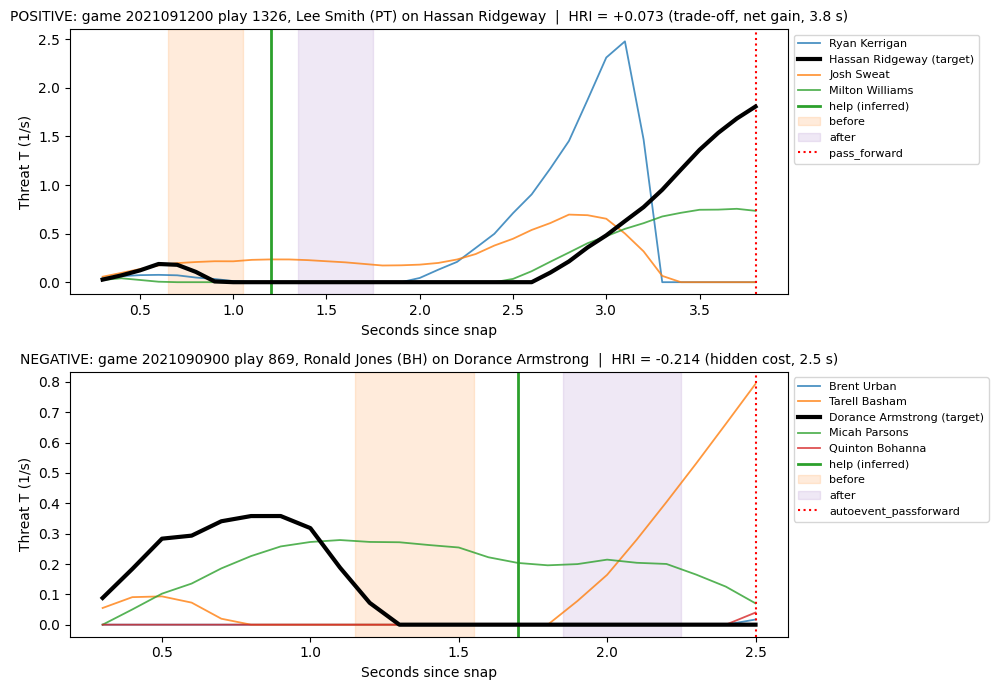

eligible for featuring: 41 of 46 scored events


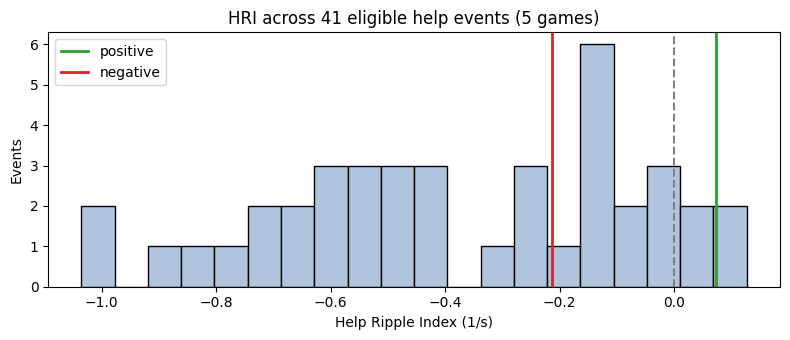

In [27]:
def plot_threat_window(ax, game_id, play_id, helper_id, target_id, title=""):
    """Rusher threat over time with help moment, windows and release. Returns the event dict."""
    trk, meta, thr = get_play(game_id, play_id)
    ev = detect_help_event(trk, meta, helper_id, target_id)
    before, after = event_windows(ev["frame"])
    to_t, half = (lambda f: (f - meta["snap_frame"]) / FPS), 0.5 / FPS
    for pid, g in thr[thr["pff_role"] == "Pass Rush"].groupby("nflId"):
        is_t = pid == target_id
        ax.plot(g["t"], g["threat_score"], label=names.get(pid, pid) + (" (target)" if is_t else ""),
                **(dict(lw=3, color="black", zorder=3) if is_t else dict(lw=1.3, alpha=0.8)))
    ax.axvline(ev["t"], color="tab:green", lw=2, label=f"help ({ev['method']})")
    ax.axvspan(to_t(before[0]) - half, to_t(before[-1]) + half, color="tab:orange", alpha=0.15, label="before")
    ax.axvspan(to_t(after[0]) - half, to_t(after[-1]) + half, color="tab:purple", alpha=0.15, label="after")
    ax.axvline(to_t(meta["end_frame"]), color="red", ls=":", label=meta["end_event"] or "end of tracking")
    ax.set_xlabel("Seconds since snap")
    ax.set_ylabel("Threat T (1/s)")
    ax.set_title(title, fontsize=10)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
    return ev

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
for ax, (k, r) in zip(axes, FEATURED.items()):
    plot_threat_window(ax, int(r["gameId"]), int(r["playId"]), int(r["helper_id"]), int(r["target_id"]),
                       f"{k.upper()}: game {r['gameId']} play {r['playId']}, {r['helper_name']} "
                       f"({r['pff_blockType']}) on {r['target_name']}  |  HRI = {r['help_ripple_index']:+.3f} "
                       f"({r['pattern']}, {r['play_seconds']:.1f} s)")
plt.tight_layout()
plt.show()

# Distribution across scored events that pass the selection filters, featured picks marked
eligible = sc[sc["end_event"].notna() & (sc["play_seconds"] <= MAX_PLAY_SECONDS)]
print(f"eligible for featuring: {len(eligible)} of {len(sc)} scored events")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(eligible["help_ripple_index"], bins=20, color="lightsteelblue", edgecolor="k")
for k, r in FEATURED.items():
    ax.axvline(r["help_ripple_index"], color="tab:green" if k == "positive" else "tab:red", lw=2, label=k)
ax.axvline(0, color="grey", ls="--")
ax.set_xlabel("Help Ripple Index (1/s)")
ax.set_ylabel("Events")
ax.set_title(f"HRI across {len(eligible)} eligible help events ({len(SCOPE_GAME_IDS)} games)")
ax.legend()
plt.tight_layout()
plt.show()


In [28]:
def featured_context(r, label):
    """Per-rusher breakdown with PFF pressure credit and the blockers PFF lists on each rusher."""
    g, p = int(r["gameId"]), int(r["playId"])
    trk, meta, thr = get_play(g, p)
    ev = detect_help_event(trk, meta, r["helper_id"], r["target_id"])
    _, per = calculate_help_ripple_index(thr, ev)

    play_pff = pff[(pff["gameId"] == g) & (pff["playId"] == p)]

    # Blockers on each rusher (PFF records each blocker's first defender), flagged if beaten
    blk = play_pff[play_pff["pff_nflIdBlockedPlayer"].notna()].copy()
    beaten = pd.Series(np.where(blk["pff_beatenByDefender"].eq(1), ", beaten", ""), index=blk.index)
    blk["blocker"] = (blk["nflId"].map(names).fillna(blk["nflId"].astype(str)) + " ("
                      + blk["pff_positionLinedUp"].fillna("?") + ", "
                      + blk["pff_blockType"].fillna("?") + beaten + ")")
    by_rusher = blk.groupby(blk["pff_nflIdBlockedPlayer"].astype("int64"))["blocker"].apply(", ".join)

    per["rusher"] = per["nflId"].map(names) + np.where(per["is_target"], " (target)", "")
    per["blocked_by"] = per["nflId"].map(by_rusher).fillna("none listed")
    per = per.join(play_pff.set_index("nflId")[["pff_hit", "pff_hurry", "pff_sack"]], on="nflId")

    desc = plays.loc[(plays["gameId"] == g) & (plays["playId"] == p), "playDescription"].iloc[0]
    print(f"{label.upper()}  game {g} play {p}  |  {meta['end_event']} at {r['play_seconds']:.1f} s  |  "
          f"result {r['passResult']}  |  helper role: {r.get('helper_pos', '?')}")
    print(f"  {desc}")
    display(per[["rusher", "before", "after", "delta", "contribution", "pff_hit", "pff_hurry",
                 "pff_sack", "blocked_by"]].round(3).sort_values("contribution"))

for k, r in FEATURED.items():
    featured_context(r, k)

# Checks on the final picks
for k, r in FEATURED.items():
    assert r["end_event"] is not None and r["play_seconds"] <= MAX_PLAY_SECONDS, f"{k} pick fails filters"
assert FEATURED["positive"]["help_ripple_index"] > 0 > FEATURED["negative"]["help_ripple_index"]
print("Task 7 checks passed.")


POSITIVE  game 2021091200 play 1326  |  pass_forward at 3.8 s  |  result C  |  helper role: TE-L
  (12:25) M.Ryan pass short right to M.Davis to ATL 35 for 9 yards (J.Sweat; E.Wilson) [H.Ridgeway].


,rusher,before,after,delta,contribution,pff_hit,pff_hurry,pff_sack,blocked_by
0,Ryan Kerrigan,0.041,0.000,-0.041,-0.000,0.0,1.0,0.0,"Kaleb McGary (RT, PA)"
2,Josh Sweat,0.209,0.209,0.000,-0.000,0.0,0.0,0.0,"Keith Smith (FB, PU)"
3,Milton Williams,0.000,0.000,0.000,-0.000,0.0,0.0,0.0,"Chris Lindstrom (RG, PA), Matt Hennessy (C, PA)"
1,Hassan Ridgeway (target),0.073,0.000,-0.073,0.073,1.0,0.0,0.0,"Lee Smith (TE-L, PT), Jake Matthews (LT, PA), ..."


NEGATIVE  game 2021090900 play 869  |  autoevent_passforward at 2.5 s  |  result C  |  helper role: HB
  (:59) T.Brady pass deep middle to A.Brown to DAL 45 for 27 yards (J.Kearse). Penalty on DAL-T.Diggs, Illegal Use of Hands, declined.


,rusher,before,after,delta,contribution,pff_hit,pff_hurry,pff_sack,blocked_by
1,Tarell Basham,0.000,0.232,0.232,-0.232,0.0,0.0,0.0,"Rob Gronkowski (TE-R, PA)"
0,Brent Urban,0.000,0.000,0.000,-0.000,0.0,0.0,0.0,"Tristan Wirfs (RT, PA)"
3,Micah Parsons,0.265,0.205,-0.061,-0.000,0.0,0.0,0.0,"Donovan Smith (LT, PP)"
4,Quinton Bohanna,0.000,0.000,0.000,-0.000,0.0,0.0,0.0,"Ryan Jensen (C, PA), Alex Cappa (RG, PA)"
2,Dorance Armstrong (target),0.018,0.000,-0.018,0.018,0.0,0.0,0.0,"Ali Marpet (LG, PA), Ronald Jones (HB, BH)"


Task 7 checks passed.


## 8. Visualise the featured plays

For each featured play:
- **Replay** (`outputs/play_replay_{positive,negative}.html`): animated field view, snap → release. The helper (green diamond), target (black ✕), QB (orange) and other rushers (red triangles) are highlighted. A dotted line joins the helper and target and turns green inside `HELP_DIST`. The title shows time, helper–target distance, target threat, and which window the frame is in.
- **Breakdown** (`outputs/metric_breakdown_{positive,negative}.png`): field at the help moment | rusher threat with windows | each rusher's contribution to HRI.

Colours use the Okabe–Ito colour-blind-safe palette, and every role also has its own marker shape, so roles don't rely on colour alone.


In [29]:
PALETTE = {"QB": "#E69F00", "Helper": "#009E73", "Target": "#000000",
           "Other rushers": "#D55E00", "Offense": "#0072B2", "Coverage": "#CC79A7"}
PLOTLY_SYMBOL = {"QB": "circle", "Helper": "diamond", "Target": "x",
                 "Other rushers": "triangle-up", "Offense": "circle", "Coverage": "circle-open"}
MPL_MARKER = {"QB": "o", "Helper": "D", "Target": "X", "Other rushers": "^", "Offense": "o", "Coverage": "o"}
CATEGORIES = list(PALETTE)
HIGHLIGHT = {"QB", "Helper", "Target"}
FIELD_COLOR = "#dcebd5"

def player_category(df, helper_id, target_id):
    """Display category per row. Helper/target take priority over their PFF role."""
    return pd.Series(np.select(
        [df["nflId"].eq(helper_id), df["nflId"].eq(target_id), df["pff_role"].eq("Pass"),
         df["pff_role"].eq("Pass Rush"), df["pff_role"].eq("Coverage")],
        ["Helper", "Target", "QB", "Other rushers", "Coverage"], default="Offense"), index=df.index)

def view_limits(trk, pad=5.0):
    """Field window that contains every player on the play, with padding."""
    return (trk["x"].min() - pad, trk["x"].max() + pad,
            max(0.0, trk["y"].min() - pad), min(53.3, trk["y"].max() + pad))

def ball_x_at_snap(meta):
    """Line of scrimmage, taken as the ball's x at the snap frame (None if unavailable)."""
    raw = load_tracking(meta["gameId"])
    b = raw[(raw["playId"] == meta["playId"]) & (raw["team"] == "football") & (raw["frameId"] == meta["snap_frame"])]
    return float(b["x"].iloc[0]) if len(b) else None

def featured_bundle(r):
    """Everything needed to draw one featured play."""
    g, p, h, t = int(r["gameId"]), int(r["playId"]), int(r["helper_id"]), int(r["target_id"])
    trk, meta, thr = get_play(g, p)
    ev = detect_help_event(trk, meta, h, t)
    summary, per = calculate_help_ripple_index(thr, ev)
    return dict(r=r, g=g, p=p, h=h, t=t, meta=meta, ev=ev, summary=summary, per=per,
                frames=thr.assign(cat=player_category(thr, h, t)))

# Synthetic test: helper with a 'Pass Route' role is still shown as Helper
_df = pd.DataFrame({"nflId": [1, 10, 11, 20, 21, 30],
                    "pff_role": ["Pass", "Pass Rush", "Pass Rush", "Pass Route", "Pass Route", "Coverage"]})
assert player_category(_df, helper_id=20, target_id=10).tolist() == \
    ["QB", "Target", "Other rushers", "Helper", "Offense", "Coverage"]
print("Synthetic category test passed.")


Synthetic category test passed.


In [37]:
def _frame_traces(fr):
    """One trace per category plus the helper-target link, in a fixed order (required for animation)."""
    traces = []
    for cat in CATEGORIES:
        d = fr[fr["cat"] == cat]
        is_open = PLOTLY_SYMBOL[cat].endswith("-open")
        traces.append(go.Scatter(
            x=d["x"], y=d["y"], mode="markers+text", name=cat,
            text=d["jerseyNumber"].astype("Int64").astype(str), textposition="top center", textfont=dict(size=9),
            hovertext=d["displayName"], hoverinfo="text",
            marker=dict(color=PALETTE[cat], symbol=PLOTLY_SYMBOL[cat], size=15 if cat in HIGHLIGHT else 11,
                        line=dict(width=2, color=PALETTE[cat]) if is_open else dict(width=1, color="white"))))

    h, t = fr[fr["cat"] == "Helper"].iloc[0], fr[fr["cat"] == "Target"].iloc[0]
    dist = float(np.hypot(h["x"] - t["x"], h["y"] - t["y"]))
    traces.append(go.Scatter(
        x=[h["x"], t["x"]], y=[h["y"], t["y"]], mode="lines", hoverinfo="skip",
        name=f"helper–target (green ≤ {HELP_DIST:g} yd)",
        line=dict(color=PALETTE["Helper"] if dist <= HELP_DIST else "grey", width=2, dash="dot")))
    return traces, dist

def _frame_title(b, frame_id, dist, head):
    ev = b["ev"]
    before, after = event_windows(ev["frame"])
    phase = ("HELP MOMENT" if frame_id == ev["frame"] else "before window" if frame_id in before
             else "after window" if frame_id in after else "")
    fr = b["frames"]
    T = fr.loc[(fr["frameId"] == frame_id) & (fr["nflId"] == b["t"]), "threat_score"].iloc[0]
    T_txt = "–" if pd.isna(T) else f"{T:.2f}"
    t_s = (frame_id - b["meta"]["snap_frame"]) / FPS
    return (f"{head}<br><sub>t = {t_s:.1f} s · helper–target {dist:.1f} yd · target threat {T_txt} /s"
            f"{'  · ' + phase if phase else ''}</sub>")



def build_replay(b, label):
    r, s, ev, fr_all = b["r"], b["summary"], b["ev"], b["frames"]
    head = (f"{label.upper()}: {r['helper_name']} ({r['pff_blockType']}) on {r['target_name']} "
            f"| HRI {s['help_ripple_index']:+.3f} ({r['pattern']})")
    frame_ids = sorted(fr_all["frameId"].unique())
    snap = b["meta"]["snap_frame"]

    frames = []
    for f in frame_ids:
        traces, dist = _frame_traces(fr_all[fr_all["frameId"] == f])
        frames.append(go.Frame(data=traces, name=str(f),
                               layout=go.Layout(title_text=_frame_title(b, f, dist, head))))
    fig = go.Figure(data=frames[0].data, frames=frames,
                    layout=go.Layout(title_text=frames[0].layout.title.text))

    # Field: yard lines every 5 yd and line of scrimmage
    x0, x1, y0, y1 = view_limits(fr_all)
    shapes = [dict(type="line", x0=xl, x1=xl, y0=0, y1=53.3, layer="below",
                   line=dict(color="white", width=1))
              for xl in range(int(np.ceil(x0 / 5)) * 5, int(x1) + 1, 5)]
    los = ball_x_at_snap(b["meta"])
    if los is not None:
        shapes.append(dict(type="line", x0=los, x1=los, y0=0, y1=53.3, layer="below",
                           line=dict(color=PALETTE["Offense"], width=2, dash="dash")))

    # Slider: one step per frame, but only label every 0.5 s to avoid crowding
    steps = [dict(method="animate",
                  label=f"{(f - snap) / FPS:.1f}s" if (f - snap) % 5 == 0 else "",
                  args=[[str(f)], dict(mode="immediate", frame=dict(duration=0, redraw=True),
                                       transition=dict(duration=0))])
             for f in frame_ids]

    # Score note sits on the right, under the legend, so nothing stacks below the field
    note = (f"<b>Score</b><br>"
            f"B (target benefit): {s['target_benefit']:+.3f}<br>"
            f"C (other-rusher cost): {s['other_rusher_cost']:+.3f}<br>"
            f"<b>HRI = B − C: {s['help_ripple_index']:+.3f} /s</b><br><br>"
            f"Help {ev['method']} at t = {ev['t']:.1f} s<br>"
            f"(within {HELP_DIST:g} yd for ≥ {MIN_SUSTAIN} frames)<br><br>"
            f"<i>Describes change around the<br>help moment; not a causal effect.</i><br><br>"
            f"Dashed blue line: line of scrimmage")

    fig.update_layout(
        width=1050, height=680, plot_bgcolor=FIELD_COLOR, shapes=shapes,
        margin=dict(l=60, r=280, t=90, b=110),
        legend=dict(x=1.02, y=1, xanchor="left", yanchor="top"),
        xaxis=dict(range=[x0, x1], title="x (yd)", showgrid=False, zeroline=False),
        yaxis=dict(range=[y0, y1], title="y (yd)", showgrid=False, zeroline=False,
                   scaleanchor="x", scaleratio=1),
        updatemenus=[dict(type="buttons", showactive=False, direction="left",
                          x=0, y=-0.16, xanchor="left", yanchor="top", pad=dict(t=0, r=10),
                          buttons=[
            dict(label="▶ Play", method="animate",
                 args=[None, dict(frame=dict(duration=100, redraw=True), fromcurrent=True,
                                  transition=dict(duration=0))]),
            dict(label="❚❚ Pause", method="animate",
                 args=[[None], dict(frame=dict(duration=0, redraw=False), mode="immediate")])])],
        sliders=[dict(active=0, x=0.2, len=0.8, y=-0.16, xanchor="left", yanchor="top",
                      pad=dict(t=0), currentvalue=dict(visible=False), steps=steps)],
        annotations=[dict(xref="paper", yref="paper", x=1.02, y=0.42, xanchor="left", yanchor="top",
                          showarrow=False, align="left", font=dict(size=11), text=note)])
    return fig


In [38]:
def draw_field_panel(ax, b):
    """Player positions at the help moment, with yard lines and line of scrimmage."""
    ev, fr = b["ev"], b["frames"]
    at_help = fr[fr["frameId"] == ev["frame"]]
    x0, x1, y0, y1 = view_limits(fr)

    ax.set_facecolor(FIELD_COLOR)
    for xl in range(int(np.ceil(x0 / 5)) * 5, int(x1) + 1, 5):
        ax.axvline(xl, color="white", lw=1, zorder=0)
    los = ball_x_at_snap(b["meta"])
    if los is not None:
        ax.axvline(los, color=PALETTE["Offense"], ls="--", lw=1.5, zorder=0, label="line of scrimmage")

    for cat in CATEGORIES:
        d = at_help[at_help["cat"] == cat]
        is_open = cat == "Coverage"
        ax.scatter(d["x"], d["y"], marker=MPL_MARKER[cat], s=120 if cat in HIGHLIGHT else 60,
                   label=cat, zorder=3,
                   facecolors="none" if is_open else PALETTE[cat],
                   edgecolors=PALETTE[cat] if is_open else "white",
                   linewidths=1.5 if is_open else 0.8)

    h = at_help[at_help["cat"] == "Helper"].iloc[0]
    t = at_help[at_help["cat"] == "Target"].iloc[0]
    ax.plot([h["x"], t["x"]], [h["y"], t["y"]], color=PALETTE["Helper"], ls=":", lw=2, zorder=2)

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_aspect("equal")
    ax.set_xlabel("x (yd)")
    ax.set_ylabel("y (yd)")
    ax.set_title(f"Positions at help moment (t = {ev['t']:.1f} s)", fontsize=10)
    ax.legend(fontsize=7, loc="lower left")

def draw_contribution_panel(ax, b):
    """Horizontal bars: target adds +B, each other rusher subtracts any increase; last bar is the HRI."""
    per = b["per"].copy()
    per["rusher"] = per["nflId"].map(names) + np.where(per["is_target"], " (target)", "")
    per = per.sort_values("contribution")

    labels = per["rusher"].tolist() + ["HRI (sum)"]
    vals = per["contribution"].tolist() + [b["summary"]["help_ripple_index"]]
    colors = ["#009E73" if v > 0 else "#D55E00" if v < 0 else "grey" for v in vals]

    ax.barh(labels, vals, color=colors, edgecolor="k")
    ax.axvline(0, color="k", lw=0.8)
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v:+.3f} ", va="center", ha="left" if v >= 0 else "right", fontsize=8)
    ax.set_xlabel("Contribution to HRI (1/s)")
    ax.set_title("Score breakdown: target +B, others −max(0, Δ)", fontsize=10)
    ax.margins(x=0.25)


In [39]:
def static_breakdown(b, label, path):
    """Three-panel PNG: field at help moment | threat timeline | contributions. Returns the path."""
    r, s, ev = b["r"], b["summary"], b["ev"]
    fig = plt.figure(figsize=(17, 5.2))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.5, 1.0], wspace=0.35)
    ax0, ax1, ax2 = (fig.add_subplot(gs[0, i]) for i in range(3))

    draw_field_panel(ax0, b)
    plot_threat_window(ax1, b["g"], b["p"], b["h"], b["t"], "Rusher threat around the help")
    ax1.legend(fontsize=7, loc="upper left")
    draw_contribution_panel(ax2, b)

    fig.suptitle(
        f"{label.upper()}: game {b['g']} play {b['p']}, {r['helper_name']} ({r['pff_blockType']}) "
        f"on {r['target_name']}  |  B = {s['target_benefit']:+.3f}, C = {s['other_rusher_cost']:+.3f}, "
        f"HRI = {s['help_ripple_index']:+.3f} /s ({r['pattern']})", fontsize=12)
    fig.text(0.01, -0.04,
             f"Help moment {ev['method']}: helper within {HELP_DIST:g} yd of target for "
             f"≥ {MIN_SUSTAIN} frames. Windows: {WINDOW} frames each side, {GAP} transition frame excluded. "
             f"Describes change around the help moment; not a causal effect.",
             fontsize=9, style="italic")

    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    return path


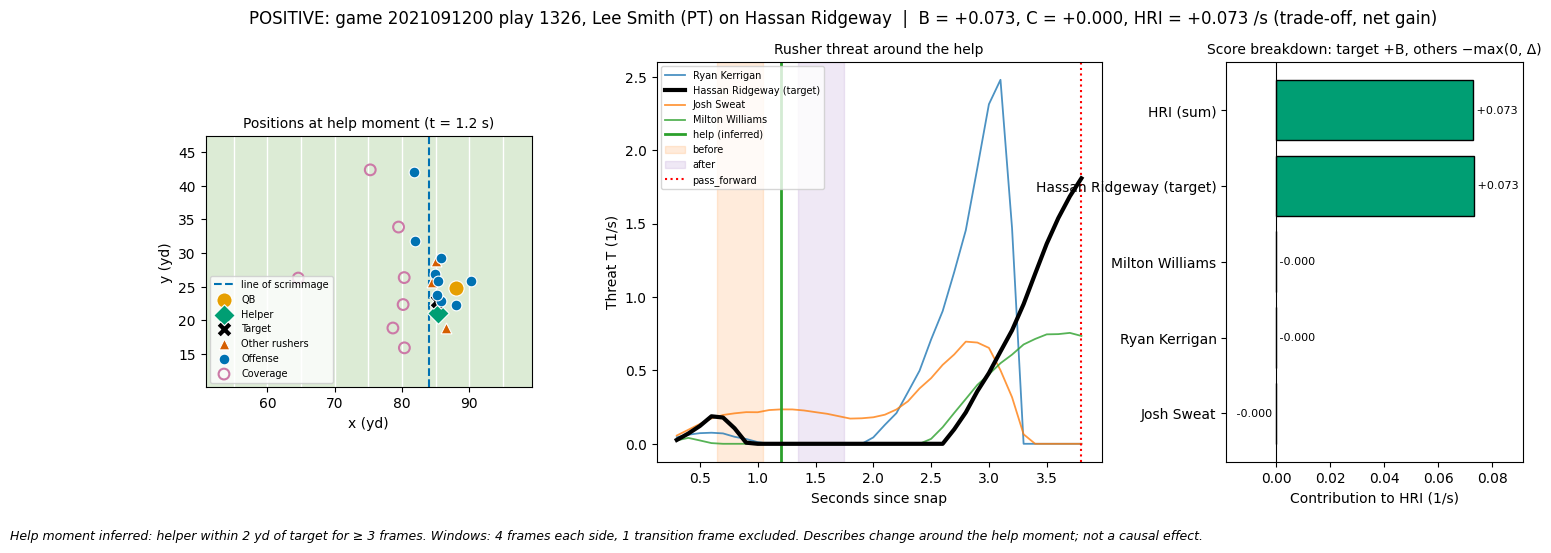

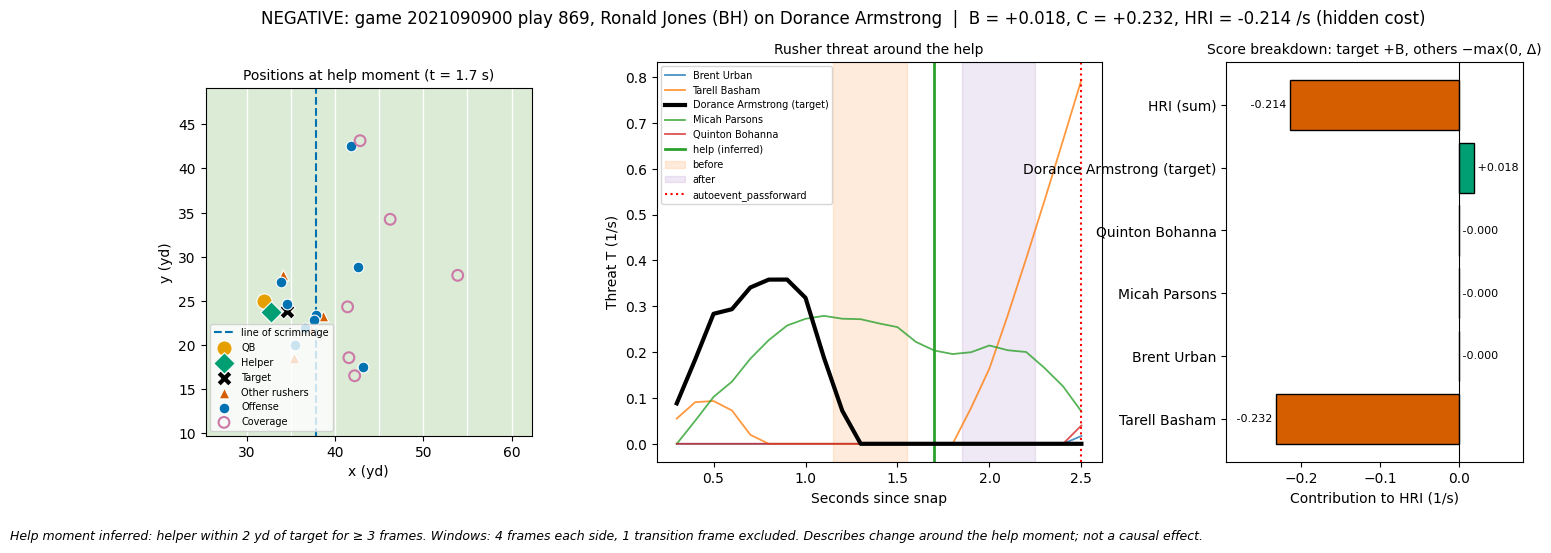

,html,png,n_frames,n_anim_frames
positive,outputs\play_replay_positive.html,outputs\metric_breakdown_positive.png,39,39
negative,outputs\play_replay_negative.html,outputs\metric_breakdown_negative.png,26,26


Task 8 checks passed.


In [41]:
from IPython.display import HTML, display

saved = {}
for label, r in FEATURED.items():
    b = featured_bundle(r)

    # Interactive replay: save to file, then embed inline without needing nbformat
    replay = build_replay(b, label)
    html_path = OUTPUT_DIR / f"play_replay_{label}.html"
    replay.write_html(html_path, include_plotlyjs="cdn", auto_play=False)
    display(HTML(replay.to_html(include_plotlyjs="cdn", full_html=False, auto_play=False)))

    # Static breakdown
    png_path = static_breakdown(b, label, OUTPUT_DIR / f"metric_breakdown_{label}.png")

    saved[label] = dict(html=html_path, png=png_path, n_frames=b["frames"]["frameId"].nunique(),
                        n_anim_frames=len(replay.frames))

# Checks
for label, info in saved.items():
    for kind in ("html", "png"):
        assert info[kind].exists() and info[kind].stat().st_size > 0, f"{label} {kind} missing or empty"
    assert info["n_anim_frames"] == info["n_frames"], f"{label}: animation frames don't match play frames"

display(pd.DataFrame(saved).T)
print("Task 8 checks passed.")


In [ ]:
pip install nbformat>=4.2.0

Note: you may need to restart the kernel to use updated packages.


c:\Python312\python.exe: No module named pip
